### 유방암 딥러닝으로 분류

202435119 한여원

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras import models, layers

In [14]:
df = pd.read_csv(r'D:\hanyeowon\Coding\pythonworks\deep\data\breast_cancer.csv')
y = df['label']
y = pd.get_dummies(y).values

X = df.drop("label", axis=1)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

In [15]:
# 전처리하기, X는 표준분표의 형태로 만들고 y는 원핫 인코딩을 한다
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [16]:
model = models.Sequential([
    layers.Dense(64, activation="relu", input_shape=(X.shape[1], )),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dense(y.shape[1], activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50


d:\hanyeowon\Coding\pythonworks\deep\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8353 - loss: 0.4442 - val_accuracy: 0.9186 - val_loss: 0.2442
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9265 - loss: 0.2112 - val_accuracy: 0.9535 - val_loss: 0.1355
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9529 - loss: 0.1431 - val_accuracy: 0.9884 - val_loss: 0.0964
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9676 - loss: 0.1014 - val_accuracy: 0.9767 - val_loss: 0.0755
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9794 - loss: 0.0825 - val_accuracy: 0.9767 - val_loss: 0.0654
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9824 - loss: 0.0713 - val_accuracy: 0.9767 - val_loss: 0.0658
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9765 - loss: 0.0664 - val_accuracy: 0.9767 - val_loss: 0.0568
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9824 - loss: 0.0421 - val_accuracy: 0.9767 - val_loss: 0.0510
Ep

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


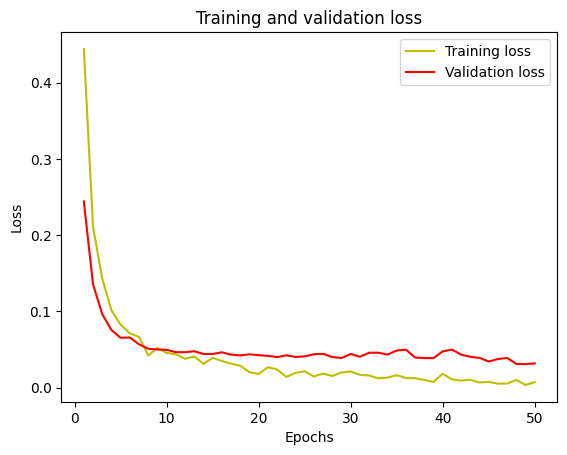

In [17]:
y_pred = model.predict(X_test_scaled)

y_test_class = np.argmax(y_test, axis=1)
y_pred_class = np.argmax(y_pred, axis=1)

loss = history.history['loss']
val_loss = history.history['val_loss']
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
import matplotlib.pyplot as plt

epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [18]:
print(loss)
print(val_loss)
print(acc)

[0.4442252218723297, 0.21115437150001526, 0.1431458741426468, 0.10137289762496948, 0.08246876299381256, 0.07131058722734451, 0.06641467660665512, 0.04210119694471359, 0.05217750743031502, 0.045552100986242294, 0.043700430542230606, 0.03780417516827583, 0.04097132012248039, 0.031186135485768318, 0.039062466472387314, 0.03501151129603386, 0.03136199340224266, 0.02872392348945141, 0.020248237997293472, 0.017915677279233932, 0.02672029659152031, 0.023891519755125046, 0.014099945314228535, 0.019302859902381897, 0.021385643631219864, 0.01458108238875866, 0.01844821497797966, 0.015200956724584103, 0.019905243068933487, 0.021245386451482773, 0.016768697649240494, 0.01589447818696499, 0.012195278890430927, 0.01305800024420023, 0.01633497141301632, 0.012707097455859184, 0.01247464306652546, 0.010200543329119682, 0.007455796934664249, 0.018205685541033745, 0.010756224393844604, 0.009220204316079617, 0.01029449887573719, 0.006761379074305296, 0.007562482263892889, 0.00523213017731905, 0.0053795822

In [19]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test_class,y_pred_class))
print(confusion_matrix(y_test_class,y_pred_class))

              precision    recall  f1-score   support

           0       0.91      0.94      0.93        53
           1       0.97      0.94      0.96        90

    accuracy                           0.94       143
   macro avg       0.94      0.94      0.94       143
weighted avg       0.94      0.94      0.94       143

[[50  3]
 [ 5 85]]
